In [ ]:
# https://chatgpt.com/share/69e12940-0570-83e8-842f-0dde48ab5eac


In [42]:
import sklearn
from sklearn.model_selection import train_test_split, cross_validate
from sklearn.datasets import fetch_openml
import matplotlib.pyplot as plt

In [ ]:
# 1
# Load MNIST and inspect the data
# Recreate fetch_openml(..., as_frame=False), inspect X, y, print shapes, and plot one digit by reshaping it to 28×28. The point is to connect the flat 784-feature vector to the image.

dataset = fetch_openml(name="mnist_784", version=1, as_frame=False)
X, y = dataset["data"], dataset["target"]

SyntaxError: invalid character '×' (U+00D7) (1312769333.py, line 2)

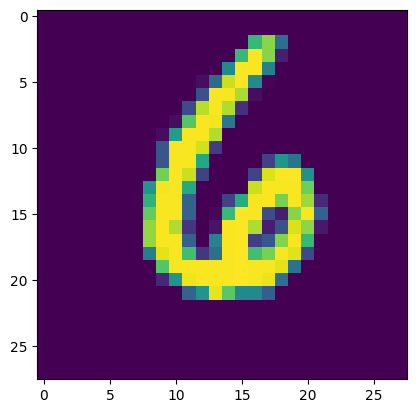

In [ ]:
plt.imshow(X[431].reshape(28,28)) #heatmap in matplotlib, why matplot lib, as I would have to hand how to make box at what distance and which row etc then color based on the value

In [ ]:
# 2
# Make the train/test split exactly as the chapter does
# Split the first 60,000 samples for training and the last 10,000 for testing. Check that the training set is already shuffled and understand why that matters for cross-validation stability
X_train, y_train, X_test, y_test = train_test_split(X, y, test_size=0.1, random_state=42)
print(X_test[0])
# cross validation don't do the randomization so we need to other wise if first 10000 are 1 and 2 only than the test might not contain these file

8


In [ ]:
# 3
# Build a binary “5 detector”
# Create boolean targets like y_train_5 and y_test_5, then train SGDClassifier(random_state=42) and predict a single sample. This is the chapter’s first classifier example.
y_test_5 = y_test == '5'
X_test_5 = X_test =='5'

print(y_test_5)

from sklearn.linear_model import SGDClassifier

model = SGDClassifier(random_state=42)
model.fit(X_train, X_test_5)

from sklearn.metrics import accuracy_score
predictions = model.predict(y_train)

accuracy_score(predictions, y_test_5)

[False False False ...  True False False]


0.9644285714285714

In [ ]:
# 4
# Measure accuracy with cross-validation, then break your own confidence with a dummy baseline
# Run cross_val_score() on the SGD model, then compare it to a DummyClassifier. The lesson is that accuracy can look excellent even when the classifier is basically useless on imbalanced data.

cross_validate(SGDClassifier(random_state=42), X_train, X_test)


{'fit_time': array([ 95.18911982, 111.50935006, 109.34737301, 102.73037505,
        115.46250415]),
 'score_time': array([0.07117915, 0.03761721, 0.04294014, 0.03536296, 0.08482409]),
 'test_score': array([0.87698413, 0.86714286, 0.89230159, 0.86968254, 0.87412698])}

from sklearn import DummyClassifier


In [ ]:
# 5
# Implement cross-validation manually with StratifiedKFold and clone
# Rebuild the 3-fold process yourself. This is worth doing once because it makes the mechanics of model evaluation concrete
# TODO: 

In [ ]:
# 6
# Generate predictions with cross_val_predict() and build a confusion matrix
# Use cross_val_predict() for clean out-of-fold predictions, then compute confusion_matrix(). Interpret true negatives, false positives, false negatives, and true positives from the matrix entries.

# confusion matrix
#   p   n
#p  TP  FP
#n  FN  TN



In [ ]:
# 7
# Compute precision, recall, and F1
# Reproduce precision_score(), recall_score(), and f1_score(). Memorize the trade-off: precision answers “when it predicts positive, how often is it right?” and recall answers “how many real positives did it catch?”

In [34]:
# https://chatgpt.com/share/69e12940-0570-83e8-842f-0dde48ab5eac